# Volatility Regime Modeling Project

## 0. Setup and Configuration

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)

import pandas as pd

ROOT: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling


Configs

In [3]:
RUN_INGESTION = False  # set True if you want to refetch/clean/merge in notebook

START_DATE = "2018-01-01"
ASSET_TICKERS = ["SPY", "QQQ", "AAPL"]
VIX_TICKERS = ["^VIX"]

RAW_DIR = ROOT / "data" / "raw"
CLEAN_DIR = ROOT / "data" / "clean"
INTERIM_DIR = ROOT / "data" / "interim"
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports" / "baselines"

RAW_ASSETS_PATH = RAW_DIR / "ohlcv_SPY-QQQ-AAPL_2018-01-01_latest_1d.parquet"
RAW_VIX_PATH = RAW_DIR / "vix_VIX_2018-01-01_latest_1d.parquet"

CLEAN_ASSETS_PATH = CLEAN_DIR / "assets_clean.parquet"
CLEAN_VIX_PATH = CLEAN_DIR / "vix_clean.parquet"

MERGED_PATH = INTERIM_DIR / "ohlcv_with_vix.parquet"
FEATURES_PATH = PROCESSED_DIR / "vol_features_5d.parquet"

HORIZON_DAYS = 5
TRAIN_END = "2022-12-30"
VAL_START = "2023-01-03"
VAL_END = "2023-12-29"
TEST_START = "2024-01-02"
N_REGIMES = 3

## Data Ingestion and Preparation

### 1.1 Data Ingestion

In [4]:
from src.pipeline.ingest import FetchSpec, fetch_ohlcv, clean_ohlcv, merge_assets_with_vix

if RUN_INGESTION:
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    CLEAN_DIR.mkdir(parents=True, exist_ok=True)
    INTERIM_DIR.mkdir(parents=True, exist_ok=True)

    # Fetch rawa
    assets_raw = fetch_ohlcv(FetchSpec(tickers=ASSET_TICKERS, start=START_DATE))
    vix_raw = fetch_ohlcv(FetchSpec(tickers=VIX_TICKERS, start=START_DATE))

    assets_raw.to_parquet(RAW_ASSETS_PATH, index=False)
    vix_raw.to_parquet(RAW_VIX_PATH, index=False)

    # Clean
    assets_clean = clean_ohlcv(assets_raw)
    vix_clean = clean_ohlcv(vix_raw)

    assets_clean.to_parquet(CLEAN_ASSETS_PATH, index=False)
    vix_clean.to_parquet(CLEAN_VIX_PATH, index=False)

    # Merge
    merged = merge_assets_with_vix(assets_clean, vix_clean)
    merged.to_parquet(MERGED_PATH, index=False)

    print("Ingestion complete:", MERGED_PATH)

else:
    print("Skipping ingestion. Expecting merged file at:", MERGED_PATH)

Skipping ingestion. Expecting merged file at: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling/data/interim/ohlcv_with_vix.parquet


### 1.2 Load Merged Data

In [5]:
df = pd.read_parquet(MERGED_PATH)
df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())
print("Tickers:", sorted(df["ticker"].astype(str).unique()))
df.head()

Shape: (6123, 13)
Date range: 2018-01-02 → 2026-02-13
Tickers: ['AAPL', 'QQQ', 'SPY']


,date,ticker,open,high,low,close,adj_close,volume,vix_close,vix_volume,vix_log_return,vix_rv_10,vix_rv_20
0,2018-01-02,AAPL,42.540001,43.075001,42.314999,43.064999,40.304176,102223600,9.77,0,NaN,NaN,NaN
1,2018-01-03,AAPL,43.132500,43.637501,42.990002,43.057499,40.297157,118071600,9.15,0,-0.065563,NaN,NaN
2,2018-01-04,AAPL,43.134998,43.367500,43.020000,43.257500,40.484325,89738400,9.22,0,0.007621,NaN,NaN
3,2018-01-05,AAPL,43.360001,43.842499,43.262501,43.750000,40.945263,94640000,9.22,0,0.000000,NaN,NaN
4,2018-01-08,AAPL,43.587502,43.902500,43.482498,43.587502,40.793182,82271200,9.52,0,0.032020,NaN,NaN


## 2, Feature Engineering and Label Construction

### 2.1 Build Features and Forward Labels

In [10]:
from src.pipeline.features import build_features_and_labels

# load merged data (assuming you already read it above)
# merged_df = pd.read_parquet(MERGED_PATH)

feat = build_features_and_labels(
    merged_df=df,
    horizon_days=HORIZON_DAYS,
    rv_windows=(10, 20, 60),
    vol_windows=(10, 20),
    train_end=TRAIN_END,
    n_regimes=N_REGIMES,
)

print("feat shape:", feat.shape)
print("date range:", feat["date"].min().date(), "→", feat["date"].max().date())
print("tickers:", feat["ticker"].unique())

# save for reuse
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
feat.to_parquet(FEATURES_PATH, index=False)
print("Saved:", FEATURES_PATH)

feat shape: (5928, 30)
date range: 2018-03-29 → 2026-02-06
tickers: <ArrowStringArray>
['AAPL', 'QQQ', 'SPY']
Length: 3, dtype: str
Saved: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling/data/processed/vol_features_5d.parquet


### 2.2 Forward Volatility Ditribution Visual

In [ ]:
import os, matplotlib.pyplot as plt

os.makedirs("report_figures", exist_ok=True)
ycol = f"fwd_rv_{HORIZON_DAYS}"

plt.figure(figsize=(7,4))
plt.hist(feat[ycol], bins=50)
plt.title("Forward 5-Day Realized Volatility Distribution")
plt.xlabel("Forward 5-Day Annualized Volatility")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("report_figures/fwd_vol_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: report_figures/fwd_vol_distribution.png")


### 2.3 Regime Label Sanity Checks

In [22]:
# confirm key columns exist
check_cols = [
    "log_return",
    f"fwd_rv_{HORIZON_DAYS}",
    "regime",
    "rv_10", "rv_20",
    "log_return_lag1", "log_return_lag2", "log_return_lag3", "log_return_lag5",
    "vix_close"
]
missing = [c for c in check_cols if c not in feat.columns]
print("Missing expected cols:", missing)

# regime distribution overall + by ticker
display(feat["regime"].value_counts().sort_index())
display(feat.groupby("ticker")["regime"].value_counts().sort_index())

Missing expected cols: []


regime
0    2241
1    2137
2    1550
Name: count, dtype: int64

ticker  regime
AAPL    0          433
        1          743
        2          800
QQQ     0          691
        1          771
        2          514
SPY     0         1117
        1          623
        2          236
Name: count, dtype: int64

## 3. Supervised Learning

### 3.1 Chronological Train/Val/Test Split
We use a fixed chronological split to avoid leakage:
- Train: up to TRAIN_END
- Validation: VAL_START to VAL_END
- Test: TEST_START onward

In [23]:
import numpy as np
import pandas as pd

from src.pipeline.train import SplitSpec, time_split_3way

TARGET = "regime"

split = SplitSpec(
    train_end=TRAIN_END,
    val_start=VAL_START,
    val_end=VAL_END,
    test_start=TEST_START,
)

train_df, val_df, test_df = time_split_3way(feat, split)

print("=== Split ===")
print({
    "train": {"start": str(train_df["date"].min().date()), "end": str(train_df["date"].max().date()), "n": len(train_df)},
    "val":   {"start": str(val_df["date"].min().date()),   "end": str(val_df["date"].max().date()),   "n": len(val_df)},
    "test":  {"start": str(test_df["date"].min().date()),  "end": str(test_df["date"].max().date()),  "n": len(test_df)},
})

=== Split ===
{'train': {'start': '2018-03-29', 'end': '2022-12-30', 'n': 3597}, 'val': {'start': '2023-01-03', 'end': '2023-12-29', 'n': 750}, 'test': {'start': '2024-01-02', 'end': '2026-02-06', 'n': 1581}}


### 3.2 Feature Matrix Definition (Leakage-safe)
We exclude forward-looking columns (fwd_*) and identifiers (date, ticker) from the feature matrix.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# exclude forward-looking columns
fwd_cols = [c for c in feat.columns if c.startswith("fwd_") or c.startswith("fwd")]
drop_cols = {TARGET, "date", "ticker", *fwd_cols}

feature_cols = [
    c for c in feat.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(feat[c])
]

print("Dropped forward cols:", fwd_cols)
print("#features:", len(feature_cols))
print("Example features:", feature_cols[:12])

preprocessor = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), feature_cols)],
    remainder="drop",
)

Dropped forward cols: ['fwd_rv_5']
#features: 26
Example features: ['open', 'high', 'low', 'close', 'adj_close', 'volume', 'vix_close', 'vix_volume', 'vix_log_return', 'vix_rv_10', 'vix_rv_20', 'log_return']


### 3.3 Baseline Models
We train two supervised baselines:
- Logistic Regression (linear baseline)
- HistGradientBoostingClassifier (strong nonlinear tabular model)

We report Accuracy and Macro F1 on validation and test.

In [25]:
import json
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

def eval_model(model, df, split_name):
    X = df[feature_cols]
    y = df[TARGET].astype(int).values
    pred = model.predict(X)
    return {
        f"{split_name}_acc": float(accuracy_score(y, pred)),
        f"{split_name}_macro_f1": float(f1_score(y, pred, average="macro")),
        f"{split_name}_confusion": confusion_matrix(y, pred, labels=[0,1,2]).tolist(),
        "pred": pred,
    }

models = {
    "logreg_baseline": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=4000, C=1.0, class_weight=None)),
    ]),
    "hgboost_baseline": Pipeline([
        ("prep", preprocessor),
        ("clf", HistGradientBoostingClassifier(
            random_state=42,
            max_iter=300,
            learning_rate=0.05,
        )),
    ]),
}

baseline_results = {}
for name, model in models.items():
    model.fit(train_df[feature_cols], train_df[TARGET].astype(int))
    val_out = eval_model(model, val_df, "val")
    test_out = eval_model(model, test_df, "test")

    baseline_results[name] = {
        "val_acc": val_out["val_acc"],
        "val_macro_f1": val_out["val_macro_f1"],
        "val_confusion": val_out["val_confusion"],
        "test_acc": test_out["test_acc"],
        "test_macro_f1": test_out["test_macro_f1"],
        "test_confusion": test_out["test_confusion"],
    }

print(json.dumps(baseline_results, indent=2))

{
  "logreg_baseline": {
    "val_acc": 0.5306666666666666,
    "val_macro_f1": 0.4301155879726688,
    "val_confusion": [
      [
        195,
        112,
        6
      ],
      [
        133,
        193,
        44
      ],
      [
        15,
        42,
        10
      ]
    ],
    "test_acc": 0.5142314990512334,
    "test_macro_f1": 0.46594351320369864,
    "test_confusion": [
      [
        457,
        263,
        9
      ],
      [
        244,
        292,
        32
      ],
      [
        57,
        163,
        64
      ]
    ]
  },
  "hgboost_baseline": {
    "val_acc": 0.5106666666666667,
    "val_macro_f1": 0.419389500340048,
    "val_confusion": [
      [
        223,
        74,
        16
      ],
      [
        166,
        147,
        57
      ],
      [
        19,
        35,
        13
      ]
    ],
    "test_acc": 0.519291587602783,
    "test_macro_f1": 0.44891274591101205,
    "test_confusion": [
      [
        531,
        169,
        29
      ],

### 3.4 Baseline Confusion Matrices
We visualize confusion matrices for validation and test splits.

In [ ]:
import os, matplotlib.pyplot as plt
import numpy as np

os.makedirs("report_figures", exist_ok=True)
CLASS_NAMES = ["Low", "Mid", "High"]

def plot_cm(cm, title, fname):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
    ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"report_figures/{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: report_figures/{fname}.png")

for name, m in baseline_results.items():
    safe = name.lower().replace(" ", "_")
    plot_cm(m["val_confusion"],  f"{name} — VAL",  f"cm_{safe}_val")
    plot_cm(m["test_confusion"], f"{name} — TEST", f"cm_{safe}_test")


### 3.5 Time-Series Cross-Validation
We use expanding-window CV within the training period to assess temporal robustness.

In [ ]:
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.metrics import f1_score

os.makedirs("report_figures", exist_ok=True)

def ts_cv_macro_f1(model, df, n_splits=5):
    """Expanding-window CV (TimeSeriesSplit) on a pre-sorted dataframe."""
    X = df[feature_cols].reset_index(drop=True)
    y = df[TARGET].astype(int).values
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
        m = clone(model)
        m.fit(X.iloc[tr_idx], y[tr_idx])
        pred = m.predict(X.iloc[te_idx])
        scores.append(float(f1_score(y[te_idx], pred, average="macro")))
    return scores

train_only = train_df.sort_values("date").reset_index(drop=True)

cv_scores = {}
for name, model in models.items():
    fold_scores = ts_cv_macro_f1(model, train_only, n_splits=5)
    cv_scores[name] = {
        "fold_macro_f1": fold_scores,
        "mean_macro_f1": float(np.mean(fold_scores)),
        "std_macro_f1":  float(np.std(fold_scores)),
    }
    print(f"{name}: mean={np.mean(fold_scores):.4f}  std={np.std(fold_scores):.4f}  folds={[round(s,4) for s in fold_scores]}")

# ── Bar chart with error bars ──────────────────────────────────────────────────
names  = list(cv_scores.keys())
means  = [cv_scores[n]["mean_macro_f1"] for n in names]
stds   = [cv_scores[n]["std_macro_f1"]  for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names, means, yerr=stds, capsize=6, color=["steelblue","darkorange"], alpha=0.85)
ax.set_ylabel("Macro F1")
ax.set_title("5-Fold TimeSeriesSplit CV — Macro F1 (mean ± std)")
ax.set_ylim(0, max(means) + max(stds) + 0.1)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.01, f"{m:.4f}\n±{s:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("report_figures/cv_macro_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: report_figures/cv_macro_f1.png")


### 3.6 Hyperparameter Tuning

#### 3.6.1 Logistic Regression
We tune regularization strength (C) and class weighting, selecting by validation Macro F1.

In [28]:
from sklearn.linear_model import LogisticRegression

C_grid = [0.01, 0.1, 1.0, 10.0, 100.0]
cw_grid = [None, "balanced"]

logreg_tuning = []

for C in C_grid:
    for cw in cw_grid:
        model = Pipeline([
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=4000, C=C, class_weight=cw)),
        ])
        model.fit(train_df[feature_cols], train_df[TARGET].astype(int))
        pred_val = model.predict(val_df[feature_cols])
        logreg_tuning.append({
            "C": C,
            "class_weight": cw,
            "val_macro_f1": float(f1_score(val_df[TARGET].astype(int), pred_val, average="macro")),
            "val_acc": float(accuracy_score(val_df[TARGET].astype(int), pred_val)),
        })

logreg_tuning_df = pd.DataFrame(logreg_tuning).sort_values("val_macro_f1", ascending=False)
display(logreg_tuning_df)
best_logreg = logreg_tuning_df.iloc[0].to_dict()
print("Best LogReg:", best_logreg)

,C,class_weight,val_macro_f1,val_acc
4,1.00,NaN,0.430116,0.530667
5,1.00,balanced,0.430116,0.530667
6,10.00,NaN,0.422262,0.510667
7,10.00,balanced,0.422262,0.510667
8,100.00,NaN,0.419489,0.510667
9,100.00,balanced,0.419489,0.510667
2,0.10,NaN,0.395522,0.514667
3,0.10,balanced,0.395522,0.514667
0,0.01,NaN,0.380126,0.506667
1,0.01,balanced,0.380126,0.506667


Best LogReg: {'C': 1.0, 'class_weight': nan, 'val_macro_f1': 0.4301155879726688, 'val_acc': 0.5306666666666666}


#### 3.6.2 HistGradientBoosting
We tune depth/regularization and learning dynamics, selecting by validation Macro F1.

In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier

grid = []
for max_depth in [2, 3, None]:
    for min_samples_leaf in [20, 50, 100]:
        for lr in [0.03, 0.05, 0.1]:
            for max_iter in [200, 400]:
                model = Pipeline([
                    ("prep", preprocessor),
                    ("clf", HistGradientBoostingClassifier(
                        random_state=42,
                        max_depth=max_depth,
                        min_samples_leaf=min_samples_leaf,
                        learning_rate=lr,
                        max_iter=max_iter,
                    )),
                ])
                model.fit(train_df[feature_cols], train_df[TARGET].astype(int))
                pred_val = model.predict(val_df[feature_cols])
                grid.append({
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "learning_rate": lr,
                    "max_iter": max_iter,
                    "val_macro_f1": float(f1_score(val_df[TARGET].astype(int), pred_val, average="macro")),
                    "val_acc": float(accuracy_score(val_df[TARGET].astype(int), pred_val)),
                })

hgb_tuning_df = pd.DataFrame(grid).sort_values("val_macro_f1", ascending=False)
display(hgb_tuning_df.head(20))
best_hgb = hgb_tuning_df.iloc[0].to_dict()
print("Best HGB:", best_hgb)

,max_depth,min_samples_leaf,learning_rate,max_iter,val_macro_f1,val_acc
34,3.0,100,0.10,200,0.432109,0.518667
27,3.0,50,0.05,400,0.431797,0.532000
46,NaN,50,0.10,200,0.427250,0.496000
44,NaN,50,0.05,200,0.426453,0.514667
23,3.0,20,0.10,400,0.426409,0.533333
33,3.0,100,0.05,400,0.425270,0.521333
39,NaN,20,0.05,400,0.423975,0.509333
51,NaN,100,0.05,400,0.423654,0.508000
53,NaN,100,0.10,400,0.421901,0.513333
48,NaN,100,0.03,200,0.421022,0.516000


Best HGB: {'max_depth': 3.0, 'min_samples_leaf': 100.0, 'learning_rate': 0.1, 'max_iter': 200.0, 'val_macro_f1': 0.43210921916721484, 'val_acc': 0.5186666666666667}


### 3.7 Final Supervised Evaluation
We re-train tuned configurations on Train and evaluate on Validation and Test.
We also save metrics artifacts for reproducible plots and report integration.

In [33]:
import os, json

# cast HGB params safely (pandas may give floats)
max_depth = None if pd.isna(best_hgb["max_depth"]) or best_hgb["max_depth"] is None else int(best_hgb["max_depth"])
min_samples_leaf = int(best_hgb["min_samples_leaf"])
learning_rate = float(best_hgb["learning_rate"])
max_iter = int(best_hgb["max_iter"])

# --- sanitize best_logreg values coming from pandas ---
best_C = float(best_logreg["C"])

cw = best_logreg.get("class_weight", None)
# pandas may store None as NaN
if cw is None or (isinstance(cw, float) and pd.isna(cw)):
    cw = None
else:
    cw = str(cw)  # should be "balanced" if not None

# tuned models
final_models = {
    "logreg_final": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            max_iter=4000,
            C=best_C,
            class_weight=cw,
        )),
    ]),
    "hgboost_tuned": Pipeline([
        ("prep", preprocessor),
        ("clf", HistGradientBoostingClassifier(
            random_state=42,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            learning_rate=learning_rate,
            max_iter=max_iter,
        )),
    ]),
}

final_results = {}
pred_frames = []

for name, model in final_models.items():
    model.fit(train_df[feature_cols], train_df[TARGET].astype(int))

    val_out = eval_model(model, val_df, "val")
    test_out = eval_model(model, test_df, "test")

    final_results[name] = {
        "val_acc": val_out["val_acc"],
        "val_macro_f1": val_out["val_macro_f1"],
        "val_confusion": val_out["val_confusion"],
        "test_acc": test_out["test_acc"],
        "test_macro_f1": test_out["test_macro_f1"],
        "test_confusion": test_out["test_confusion"],
    }

    for split_name, df, pred in [("val", val_df, val_out["pred"]), ("test", test_df, test_out["pred"])]:
        tmp = df[["date", "ticker", TARGET]].copy()
        tmp["split"] = split_name
        tmp["model"] = name
        tmp["pred"] = pred
        pred_frames.append(tmp)

print(json.dumps(final_results, indent=2))

# save artifacts
os.makedirs("data/processed", exist_ok=True)

with open("data/processed/final_supervised_metrics.json", "w") as f:
    json.dump(final_results, f, indent=2)

preds = pd.concat(pred_frames).reset_index(drop=True)
preds.to_parquet("data/processed/final_supervised_preds.parquet", index=False)

# also save model-specific metrics for your final comparison loader
with open("data/processed/final_logreg_metrics.json", "w") as f:
    json.dump(final_results["logreg_final"], f, indent=2)

with open("data/processed/final_hgboost_tuned_metrics.json", "w") as f:
    json.dump({"hgboost_tuned": {**final_results["hgboost_tuned"], "best_params": {
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "learning_rate": learning_rate,
        "max_iter": max_iter,
    }}}, f, indent=2)

print("Saved: data/processed/final_supervised_metrics.json")
print("Saved: data/processed/final_supervised_preds.parquet")
print("Saved: data/processed/final_logreg_metrics.json")
print("Saved: data/processed/final_hgboost_tuned_metrics.json")

{
  "logreg_final": {
    "val_acc": 0.5306666666666666,
    "val_macro_f1": 0.4301155879726688,
    "val_confusion": [
      [
        195,
        112,
        6
      ],
      [
        133,
        193,
        44
      ],
      [
        15,
        42,
        10
      ]
    ],
    "test_acc": 0.5142314990512334,
    "test_macro_f1": 0.46594351320369864,
    "test_confusion": [
      [
        457,
        263,
        9
      ],
      [
        244,
        292,
        32
      ],
      [
        57,
        163,
        64
      ]
    ]
  },
  "hgboost_tuned": {
    "val_acc": 0.5186666666666667,
    "val_macro_f1": 0.43210921916721484,
    "val_confusion": [
      [
        213,
        90,
        10
      ],
      [
        170,
        163,
        37
      ],
      [
        15,
        39,
        13
      ]
    ],
    "test_acc": 0.5230866540164453,
    "test_macro_f1": 0.45073721826865193,
    "test_confusion": [
      [
        537,
        170,
        22
      ],
  

### 3.8 Feature Ablation (Diagnostic)
We evaluate whether regimes are driven more by asset-only features or VIX-only features.

In [34]:
from sklearn.metrics import f1_score, accuracy_score

def make_preprocessor(cols):
    return ColumnTransformer(
        transformers=[("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), cols)],
        remainder="drop",
    )

def run_ablation(cols, model_kind="logreg_final"):
    prep = make_preprocessor(cols)
    if model_kind == "logreg_final":
        model = Pipeline([("prep", prep), ("clf", final_models["logreg_final"].named_steps["clf"])])
    else:
        model = Pipeline([("prep", prep), ("clf", final_models["hgboost_tuned"].named_steps["clf"])])

    model.fit(train_df[cols], train_df[TARGET].astype(int))
    pred = model.predict(val_df[cols])
    return float(f1_score(val_df[TARGET].astype(int), pred, average="macro"))

feat_order = ["FULL", "ASSET_ONLY", "VIX_ONLY"]
feat_sets = {
    "FULL": feature_cols,
    "ASSET_ONLY": [c for c in feature_cols if not c.startswith("vix_")],
    "VIX_ONLY": [c for c in feature_cols if c.startswith("vix_")],
}

rows = []
for set_name, cols in feat_sets.items():
    for model_kind in ["logreg_final", "hgboost_tuned"]:
        rows.append({
            "feature_set": set_name,
            "model": model_kind,
            "val_macro_f1": run_ablation(cols, model_kind=model_kind),
            "n_features": len(cols),
        })

ablation_results = pd.DataFrame(rows)
display(ablation_results)

,feature_set,model,val_macro_f1,n_features
0,FULL,logreg_final,0.430116,26
1,FULL,hgboost_tuned,0.432109,26
2,ASSET_ONLY,logreg_final,0.384621,18
3,ASSET_ONLY,hgboost_tuned,0.403387,18
4,VIX_ONLY,logreg_final,0.335934,8
5,VIX_ONLY,hgboost_tuned,0.392390,8


### 3.9 Failure Analysis (Supervised)
We inspect misclassification patterns and extract representative errors for qualitative analysis.

In [36]:
preds = pd.read_parquet("data/processed/final_supervised_preds.parquet").copy()
preds["true"] = preds[TARGET].astype(int)
preds["pred"] = preds["pred"].astype(int)
preds["is_error"] = preds["true"] != preds["pred"]
preds["abs_err"] = (preds["pred"] - preds["true"]).abs()

# error summary
err_summary = (preds.groupby(["model", "split"])
    .agg(n=("is_error","size"), error_rate=("is_error","mean"), mean_abs_err=("abs_err","mean"))
    .reset_index()
)
display(err_summary)

# most common confusions (TEST)
test = preds[preds["split"] == "test"]
conf_counts = (test[test["is_error"]]
    .groupby(["model","true","pred"]).size()
    .reset_index(name="count")
    .sort_values(["model","count"], ascending=[True, False])
)
display(conf_counts.head(20))

,model,split,n,error_rate,mean_abs_err
0,hgboost_tuned,test,1581,0.476913,0.547122
1,hgboost_tuned,val,750,0.481333,0.514667
2,logreg_final,test,1581,0.485769,0.527514
3,logreg_final,val,750,0.469333,0.497333


,model,true,pred,count
2,hgboost_tuned,1,0,289
0,hgboost_tuned,0,1,170
5,hgboost_tuned,2,1,138
4,hgboost_tuned,2,0,89
3,hgboost_tuned,1,2,46
1,hgboost_tuned,0,2,22
6,logreg_final,0,1,263
8,logreg_final,1,0,244
11,logreg_final,2,1,163
10,logreg_final,2,0,57


## 4. Unsupervised Learning

### 4.1 Observations Setup
We run unsupervised models on a single ticker (SPY) using a small, interpretable observation set.
We standardize using TRAIN only to avoid leakage.

In [37]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

TICKER_FOR_UNSUP = "SPY"
OBS_COLS = ["log_return", "rv_10", "vix_close"]  # small + interpretable

unsup_df = feat[feat["ticker"] == TICKER_FOR_UNSUP].copy()
unsup_df = unsup_df.sort_values("date").reset_index(drop=True)

missing = [c for c in OBS_COLS if c not in unsup_df.columns]
print("Missing OBS_COLS:", missing)

unsup_df = unsup_df.dropna(subset=OBS_COLS + [TARGET]).reset_index(drop=True)

train_end_dt  = pd.to_datetime(TRAIN_END)
val_start_dt  = pd.to_datetime(VAL_START)
val_end_dt    = pd.to_datetime(VAL_END)
test_start_dt = pd.to_datetime(TEST_START)

train_mask = unsup_df["date"] <= train_end_dt
val_mask   = (unsup_df["date"] >= val_start_dt) & (unsup_df["date"] <= val_end_dt)
test_mask  = unsup_df["date"] >= test_start_dt

print("Rows:", len(unsup_df))
print("Train/Val/Test:", train_mask.sum(), val_mask.sum(), test_mask.sum())

X = unsup_df[OBS_COLS].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X[train_mask])
X_all   = scaler.transform(X)

Missing OBS_COLS: []
Rows: 1976
Train/Val/Test: 1199 250 527


### 4.2 Unsupervised Evaluation Utilities
We report:
- ARI/NMI: agreement without label mapping
- Mapped Macro-F1/Accuracy: best state→regime mapping learned on TRAIN only

In [38]:
import itertools
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

REGIMES = sorted(unsup_df[TARGET].astype(int).unique())

def eval_ari_nmi(df, mask, state_col):
    y = df.loc[mask, TARGET].astype(int).values
    s = df.loc[mask, state_col].astype(int).values
    return {
        "ARI": float(adjusted_rand_score(y, s)),
        "NMI": float(normalized_mutual_info_score(y, s)),
        "n": int(mask.sum()),
    }

def best_mapping_train(df, train_mask, state_col, n_states=3):
    y = df.loc[train_mask, TARGET].astype(int).values
    s = df.loc[train_mask, state_col].astype(int).values

    best = None
    for perm in itertools.permutations(REGIMES, n_states):
        mapping = {i: perm[i] for i in range(n_states)}
        pred = np.array([mapping[x] for x in s])
        mf1 = f1_score(y, pred, average="macro")
        acc = accuracy_score(y, pred)
        if best is None or mf1 > best["macro_f1"]:
            best = {"mapping": mapping, "macro_f1": float(mf1), "acc": float(acc)}
    return best

def eval_mapped(df, mask, state_col, mapping):
    y = df.loc[mask, TARGET].astype(int).values
    s = df.loc[mask, state_col].astype(int).values
    pred = np.array([mapping[x] for x in s])
    return {
        "macro_f1": float(f1_score(y, pred, average="macro")),
        "acc": float(accuracy_score(y, pred)),
        "confusion": confusion_matrix(y, pred, labels=[0,1,2]).tolist(),
    }

### 4.3 K-Means (Static Clustering Baseline)
We fit K-Means with K=3 (aligned with 3 regime labels) on TRAIN only and evaluate on VAL/TEST.

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
kmeans.fit(X_train)

unsup_df["kmeans_state"] = kmeans.predict(X_all)

print("VAL ARI/NMI:", eval_ari_nmi(unsup_df, val_mask, "kmeans_state"))
print("TEST ARI/NMI:", eval_ari_nmi(unsup_df, test_mask, "kmeans_state"))

best_km = best_mapping_train(unsup_df, train_mask, "kmeans_state", n_states=3)
print("Best mapping (KMeans):", best_km["mapping"])

val_km  = eval_mapped(unsup_df, val_mask, "kmeans_state", best_km["mapping"])
test_km = eval_mapped(unsup_df, test_mask, "kmeans_state", best_km["mapping"])

print("VAL KMeans:", {k: round(v,4) if isinstance(v,float) else v for k,v in val_km.items() if k!="confusion"})
print("TEST KMeans:", {k: round(v,4) if isinstance(v,float) else v for k,v in test_km.items() if k!="confusion"})

VAL ARI/NMI: {'ARI': 0.053597218051135515, 'NMI': 0.05302972710839999, 'n': 250}
TEST ARI/NMI: {'ARI': 0.15843241239938327, 'NMI': 0.09700350885084165, 'n': 527}
Best mapping (KMeans): {0: np.int64(0), 1: np.int64(2), 2: np.int64(1)}
VAL KMeans: {'macro_f1': 0.3177, 'acc': 0.652}
TEST KMeans: {'macro_f1': 0.3927, 'acc': 0.6888}


### 4.4 Hidden Markov Model (Temporal Clustering)
We fit a 3-state Gaussian HMM on TRAIN only and decode states across the full series.

In [40]:
from hmmlearn.hmm import GaussianHMM

hmm_model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=500,
    random_state=42,
)

hmm_model.fit(X_train)
unsup_df["hmm_state"] = hmm_model.predict(X_all)

print("Converged:", hmm_model.monitor_.converged, "| iters:", hmm_model.monitor_.iter)

print("VAL ARI/NMI:", eval_ari_nmi(unsup_df, val_mask, "hmm_state"))
print("TEST ARI/NMI:", eval_ari_nmi(unsup_df, test_mask, "hmm_state"))

best_hmm = best_mapping_train(unsup_df, train_mask, "hmm_state", n_states=3)
print("Best mapping (HMM):", best_hmm["mapping"])

val_hmm  = eval_mapped(unsup_df, val_mask, "hmm_state", best_hmm["mapping"])
test_hmm = eval_mapped(unsup_df, test_mask, "hmm_state", best_hmm["mapping"])

print("VAL HMM:", {k: round(v,4) if isinstance(v,float) else v for k,v in val_hmm.items() if k!="confusion"})
print("TEST HMM:", {k: round(v,4) if isinstance(v,float) else v for k,v in test_hmm.items() if k!="confusion"})

Converged: True | iters: 44
VAL ARI/NMI: {'ARI': 0.19273484780265834, 'NMI': 0.12584933139323584, 'n': 250}
TEST ARI/NMI: {'ARI': 0.16360339950509267, 'NMI': 0.1054610141833477, 'n': 527}
Best mapping (HMM): {0: np.int64(1), 1: np.int64(2), 2: np.int64(0)}
VAL HMM: {'macro_f1': 0.4659, 'acc': 0.72}
TEST HMM: {'macro_f1': 0.5426, 'acc': 0.6565}


### 4.5 Unsupervised Visuals

#### 4.5.1 State vs Regime Heatmaps
We visualize how each unsupervised state's assignments align with the labeled regimes.

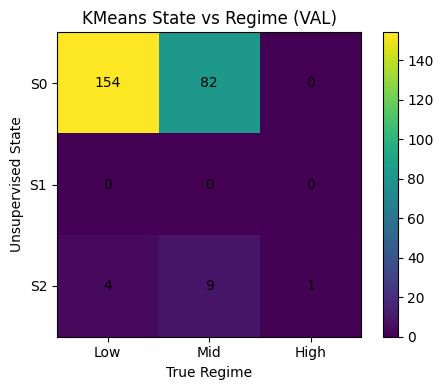

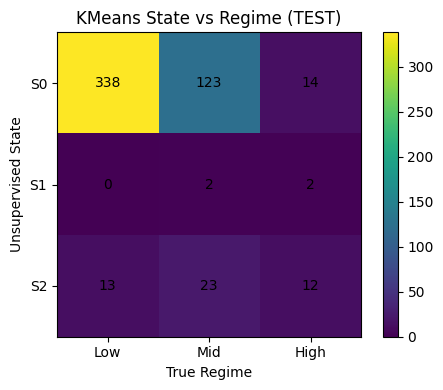

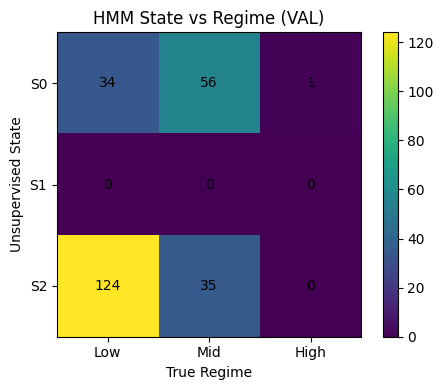

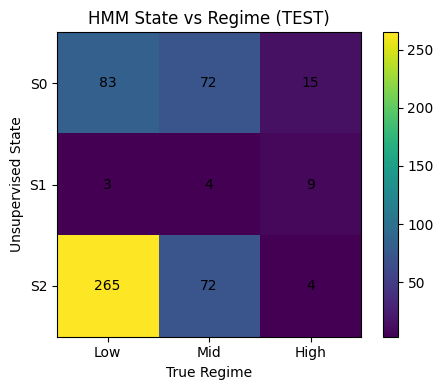

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_state_vs_regime(df, mask, state_col, title):
    sub = df.loc[mask, [state_col, TARGET]].dropna().copy()
    sub[state_col] = sub[state_col].astype(int)
    sub[TARGET] = sub[TARGET].astype(int)

    mat = pd.crosstab(sub[state_col], sub[TARGET]).reindex(index=range(3), columns=range(3), fill_value=0)
    mat = mat.values

    plt.figure(figsize=(5, 4))
    plt.imshow(mat)
    plt.title(title)
    plt.xlabel("True Regime")
    plt.ylabel("Unsupervised State")
    plt.xticks([0,1,2], ["Low","Mid","High"])
    plt.yticks([0,1,2], ["S0","S1","S2"])
    for i in range(3):
        for j in range(3):
            plt.text(j, i, str(mat[i, j]), ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# KMeans
plot_state_vs_regime(unsup_df, val_mask,  "kmeans_state", "KMeans State vs Regime (VAL)")
plot_state_vs_regime(unsup_df, test_mask, "kmeans_state", "KMeans State vs Regime (TEST)")

# HMM
plot_state_vs_regime(unsup_df, val_mask,  "hmm_state", "HMM State vs Regime (VAL)")
plot_state_vs_regime(unsup_df, test_mask, "hmm_state", "HMM State vs Regime (TEST)")

#### 4.5.2 HMM State Means
We inspect the mean observation values per hidden state to interpret what each state represents.

In [45]:
state_means = pd.DataFrame(hmm_model.means_, columns=OBS_COLS)
display(state_means)

,log_return,rv_10,vix_close
0,-0.007193,0.046148,0.094726
1,-0.066907,1.478919,1.599365
2,0.037055,-0.676645,-0.788322


#### 4.5.3 Unsupervised Model Comparison
We compare KMeans (static clustering) vs HMM (temporal clustering) using mapped Macro F1.

In [ ]:
import os, matplotlib.pyplot as plt
import numpy as np

os.makedirs("report_figures", exist_ok=True)

comp_unsup = pd.DataFrame([
    {"model": "KMeans", "val_macro_f1": val_km["macro_f1"],  "test_macro_f1": test_km["macro_f1"]},
    {"model": "HMM",    "val_macro_f1": val_hmm["macro_f1"], "test_macro_f1": test_hmm["macro_f1"]},
])
display(comp_unsup)

x = np.arange(len(comp_unsup["model"]))
w = 0.38
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.bar(x - w/2, comp_unsup["val_macro_f1"],  width=w, label="VAL",  color="steelblue")
ax.bar(x + w/2, comp_unsup["test_macro_f1"], width=w, label="TEST", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(comp_unsup["model"])
ax.set_ylabel("Macro F1")
ax.set_title("Unsupervised Comparison (Mapped Macro F1)")
ax.set_ylim(0, max(comp_unsup[["val_macro_f1","test_macro_f1"]].max()) + 0.1)
ax.legend()
plt.tight_layout()
plt.savefig("report_figures/unsupervised_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: report_figures/unsupervised_comparison.png")


#### 4.5.4 Key Unsupervised Visuals
We visualize:
- KMeans timeline (expected to be noisy)
- HMM transition matrix (persistence)
- Regime timeline: true regime vs HMM inferred state

In [ ]:
import os, matplotlib.pyplot as plt
import numpy as np

os.makedirs("report_figures", exist_ok=True)

# ── K-Means timeline ───────────────────────────────────────────────────────────
plt.figure(figsize=(12, 3))
plt.plot(unsup_df["date"], unsup_df["kmeans_state"], drawstyle="steps-post")
plt.title("K-Means Cluster State Over Time")
plt.xlabel("Date"); plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("report_figures/kmeans_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: report_figures/kmeans_timeline.png")

# ── HMM transition matrix ──────────────────────────────────────────────────────
trans_mat = hmm_model.transmat_
plt.figure(figsize=(5, 4))
plt.imshow(trans_mat, vmin=0, vmax=1)
plt.title("HMM Transition Matrix")
plt.xlabel("Next State"); plt.ylabel("Current State")
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{trans_mat[i,j]:.2f}", ha="center", va="center", color="white", fontweight="bold")
plt.colorbar()
plt.tight_layout()
plt.savefig("report_figures/hmm_transition_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: report_figures/hmm_transition_matrix.png")

# ── True regime vs HMM timeline ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(unsup_df["date"], unsup_df[TARGET].astype(int), drawstyle="steps-post")
axes[0].set_title("True 5-Day Forward Volatility Regime")
axes[0].set_ylabel("Regime")
axes[0].set_yticks([0,1,2]); axes[0].set_yticklabels(["Low","Mid","High"])
axes[1].plot(unsup_df["date"], unsup_df["hmm_state"].astype(int), drawstyle="steps-post", color="darkorange")
axes[1].set_title("HMM Inferred Hidden State")
axes[1].set_ylabel("State")
axes[1].set_yticks([0,1,2]); axes[1].set_yticklabels(["S0","S1","S2"])
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("report_figures/regime_vs_hmm_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: report_figures/regime_vs_hmm_timeline.png")


### 4.6 Save Unsupervised Artifacts
We save state assignments and summary metrics for reproducible reporting and final comparisons.

In [42]:
import os, json
import numpy as np

os.makedirs("data/processed", exist_ok=True)

def to_jsonable(x):
    if isinstance(x, (np.integer,)): return int(x)
    if isinstance(x, (np.floating,)): return float(x)
    if isinstance(x, (np.ndarray,)): return x.tolist()
    if isinstance(x, dict): return {str(k): to_jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)): return [to_jsonable(v) for v in x]
    return x

# save per-day states
cols_to_save = ["date", "ticker", TARGET] + OBS_COLS + ["kmeans_state", "hmm_state"]
unsup_df[cols_to_save].to_parquet("data/processed/unsup_states_spy.parquet", index=False)

# save summaries
kmeans_summary = {"ticker": TICKER_FOR_UNSUP, "obs_cols": OBS_COLS, "mapping": best_km["mapping"], "val": val_km, "test": test_km}
hmm_summary    = {"ticker": TICKER_FOR_UNSUP, "obs_cols": OBS_COLS, "mapping": best_hmm["mapping"], "val": val_hmm, "test": test_hmm,
                  "transmat": hmm_model.transmat_, "means": hmm_model.means_}

with open("data/processed/kmeans_summary.json", "w") as f:
    json.dump(to_jsonable(kmeans_summary), f, indent=2)

with open("data/processed/hmm_summary.json", "w") as f:
    json.dump(to_jsonable(hmm_summary), f, indent=2)

print("Saved: data/processed/unsup_states_spy.parquet")
print("Saved: data/processed/kmeans_summary.json")
print("Saved: data/processed/hmm_summary.json")

Saved: data/processed/unsup_states_spy.parquet
Saved: data/processed/kmeans_summary.json
Saved: data/processed/hmm_summary.json
